In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student_data.csv')
print("Data loaded successfully!")

Data loaded successfully!


In [16]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [17]:
df.dropna(inplace=True)
df.columns = df.columns.str.strip()
print("Data cleaned.")

Data cleaned.


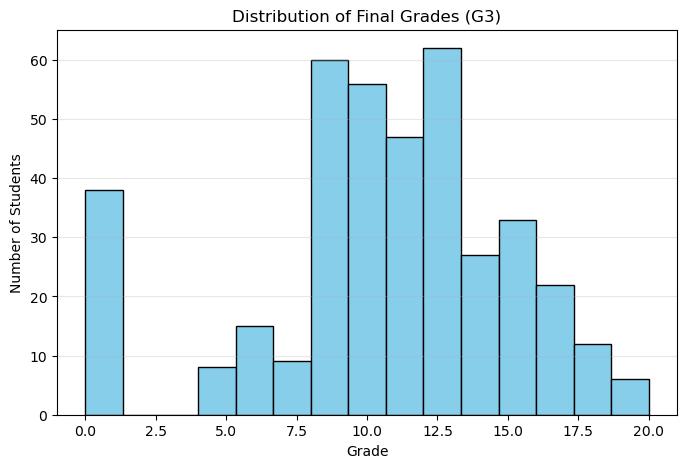

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop('G3', axis=1), drop_first=True)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

Data split into training and testing sets.


Decision Tree Accuracy: 35.44%
Random Forest Accuracy: 36.71%


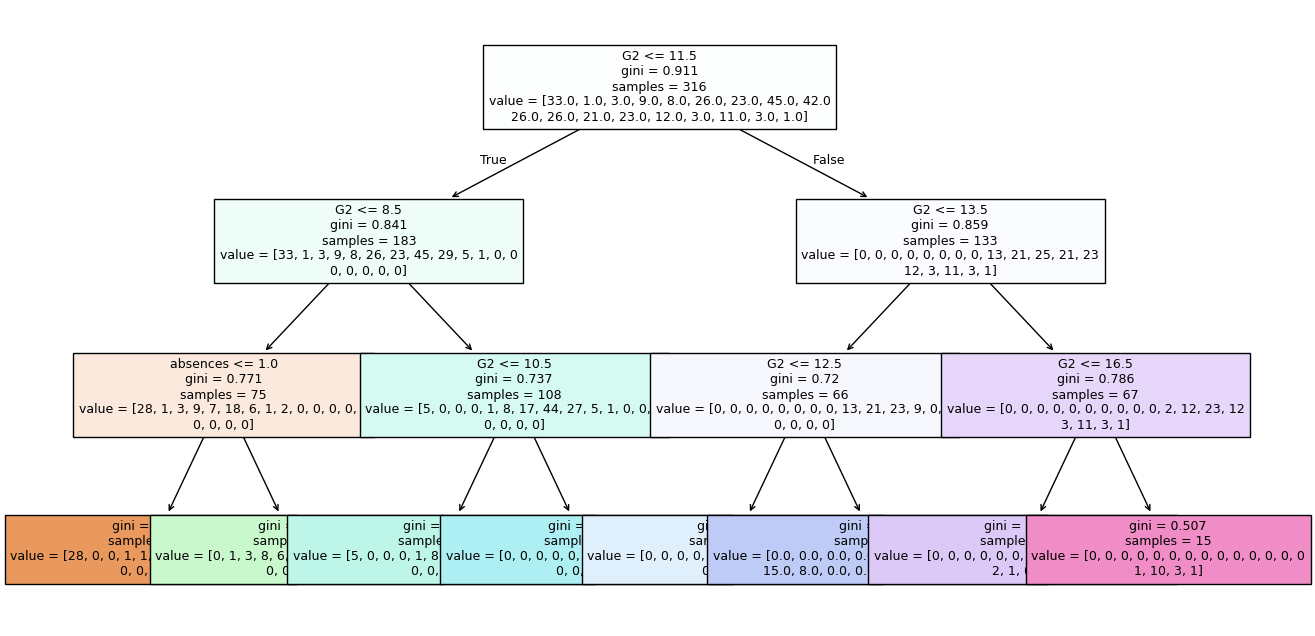

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

print(f"Decision Tree Accuracy: {dt.score(X_test, y_test)*100:.2f}%")
print(f"Random Forest Accuracy: {rf.score(X_test, y_test)*100:.2f}%")

plt.figure(figsize=(15, 8))
plot_tree(dt, feature_names=X.columns, filled=True, fontsize=9)
plt.show()

In [21]:
print(df.dtypes)

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
